
# FinAdvisor: fine-tune a transformer for financial advice

This notebook builds a lightweight financial-advice generator by fine-tuning a pretrained causal language model (GPT-2 sized) on the provided glossary `data/data_sample_1500.csv`. The notebook:
- cleans the dataset and converts each row into an instruction/response pair that asks for portfolio or planning guidance
- fine-tunes a small transformer (`distilgpt2` by default) to act as a financial advisor
- saves the model to `models/finadvisor-distilgpt2`
- demonstrates inference for custom prompts


In [17]:
!pip install --upgrade evaluate bitsandbytes accelerate peft transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 131.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2


In [14]:
import random
from torch.utils.tensorboard import SummaryWriter
import logging
import wandb
from __future__ import annotations

import torch
import datasets
from dataclasses import dataclass
from typing import Dict, List

import pandas as pd
import os
import torch
from datasets import load_dataset
import transformers
from transformers import (
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    HfArgumentParser,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    pipeline,
    logging,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, PeftModel, get_peft_model
from evaluate import load
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from accelerate import Accelerator
import datasets

In [3]:
BASE_MODEL = os.getenv("BASE_MODEL", "microsoft/Phi-3-mini-4k-instruct")  #
DATA_PATH = os.getenv("DATA_PATH", "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/data/data_sample_1500.csv")
MODEL_MS_PATH = os.getenv("MODEL_PATH", "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2")
OUTPUT_DIR = os.getenv("OUTPUT_DIR", "checkpoints/financial-glossary-gpt")


In [4]:
# Configuration
model_name = BASE_MODEL  # stronger instruction model
seed = 42
max_length = 512
output_dir = MODEL_MS_PATH
data_path = DATA_PATH

os.makedirs(output_dir, exist_ok=True)
random.seed(seed)
torch.manual_seed(seed)

In [5]:
from google.colab import drive
import os

# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    # Only remove contents if it's a directory and not already mounted
    # A safer approach is to check if it's a mount point first, but for Colab,
    # simply clearing it before mounting is usually sufficient if it's not mounted.
    if not os.path.ismount('/content/drive'):
        !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
# Load dataset

fin_ds = pd.read_csv(data_path)
fin_ds = fin_ds.dropna(subset=["terms", "definitions"])
fin_ds = fin_ds[["terms", "definitions"]]
print(f"Loaded {len(fin_ds)} rows")
fin_ds.head()


Loaded 1500 rows


,terms,definitions
0,Low/No Documentation Loan,A low/no documentation loan allows a potential...
1,Combined Loan-To-Value Ratio (CLTV Ratio),The combined loan-to-value (CLTV) ratio is the...
2,Nonforfeiture Clause,A nonforfeiture (sometimes hyphenated) clause ...
3,Discretionary spending,Government spending authorized by Congress on ...
4,DEBT TO ASSETS,"A measure of a company’s FINANCIAL LEVERAGE, o..."


In [7]:
def build_definitions(term, definition):
    # You can adjust style here (more "human" is often better)
    return f"Terms: {term}\nDefinitions: {definition}"

fin_ds["text"] = fin_ds.apply(lambda r: build_definitions(r["terms"], r["definitions"]), axis=1)
text_corpus = fin_ds["text"].tolist()

print(text_corpus[0])

Terms: Low/No Documentation Loan
Definitions: A low/no documentation loan allows a potential borrower to apply for a mortgage while providing little or no information regarding their employment, income, or assets. Regulation of these loans has evolved significantly since 2008, but they remain an option for some borrowers in nontraditional financial situations.


In [8]:
import datasets

# Convert text_corpus (list of strings) to a Hugging Face Dataset
raw_datasets = datasets.Dataset.from_dict({"text": text_corpus})

# Create the train-test split using the Dataset's method
train_test = raw_datasets.train_test_split(test_size=0.1, seed=seed)

print(train_test)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1350
    })
    test: Dataset({
        features: ['text'],
        num_rows: 150
    })
})


In [9]:
model_name

'microsoft/Phi-3-mini-4k-instruct'

In [15]:
# Load tokenizer (no change needed for TPU, but included for completeness)
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.padding_side != "right":
    tokenizer.padding_side = "right"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=False,
)

# Load model with 4-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16, # TPUs are optimized for bfloat16
    device_map="auto", # Use device_map="auto" for efficient loading of quantized models
)


# Note: The original device_map argument is typically used for multi-GPU setups.
# For single TPU core, we load the model and then explicitly move it to the XLA device.
# For multi-TPU cores, distributed training with torch_xla.distributed is used.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [17]:
# Attach LoRA adapters
lora_config = LoraConfig(
    r=16,                      # rank (adapter size)
    lora_alpha=32,             # scaling
    lora_dropout=0.05,         # regularization
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[           # typical names; adjust if needed
        "q_proj", "k_proj", "v_proj", "o_proj"
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # sanity check: only a small % trainable


trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823


In [18]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # sanity check: only a small % trainable

# Tokenize datasets
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

tokenized = train_test.map(tokenize_fn, batched=True, remove_columns=["text"])

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:78: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'microsoft/Phi-3-mini-4k-instruct' to 'None'. Please ensure that the correct base model is loaded when loading this checkpoint.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [21]:
# Training arguments (same idea as before)
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    learning_rate=5e-5,
    warmup_steps=50,
    weight_decay=0.01,
    bf16=True,                     # keep if your device supports it
    gradient_checkpointing=False, # Changed to False to fix RuntimeError
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=collator,
)

# Ensure the model is in training mode
model.train()

# This ensures inputs to the model require gradients, crucial for PEFT when base model is frozen.
model.enable_input_require_grads()

# The following loop is redundant and causes the error with quantized models.
# PEFT already handles setting `requires_grad` for the trainable LoRA parameters.
# for param in model.parameters():
#     param.requires_grad = True

trainer.train()

# Save LoRA-adapted model + tokenizer
trainer.save_model(output_dir)        # saves base config + LoRA weights
tokenizer.save_pretrained(output_dir)


Epoch,Training Loss,Validation Loss
1,1.662500,1.566220
2,1.515900,1.522053
3,1.504100,1.506686
4,1.425600,1.501483
5,1.492400,1.499441


('/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/special_tokens_map.json',
 '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/chat_template.jinja',
 '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/tokenizer.model',
 '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/added_tokens.json',
 '/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/tokenizer.json')

Checking for TensorBoard logs in: /content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/runs
Found latest log directory: /content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2/runs/Dec02_06-47-15_c5fae8119ff9


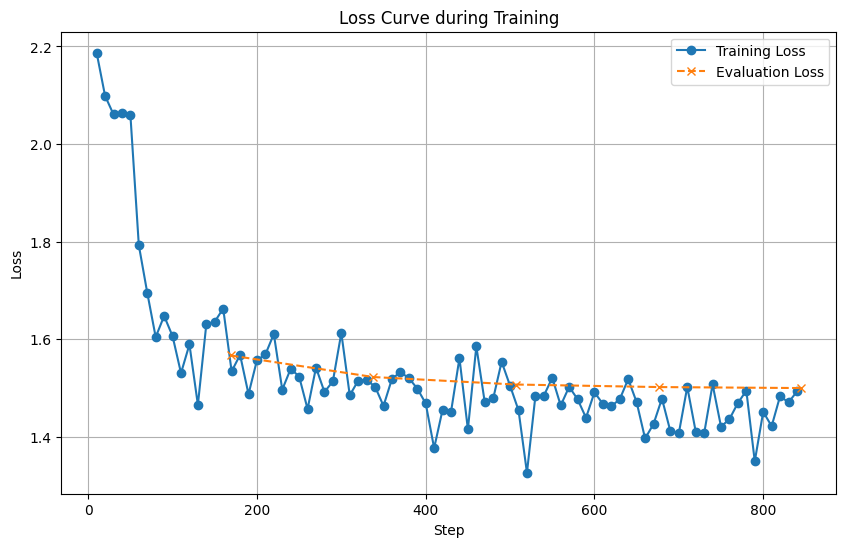

In [24]:
import json
import matplotlib.pyplot as plt
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Re-define output_dir to ensure it's accessible in this cell
MODEL_MS_PATH = os.getenv("MODEL_MS_PATH", "/content/drive/MyDrive/Colab Notebooks/aai-590-AI_Financial_advisor/models/finadvisor_Phi2")
output_dir = MODEL_MS_PATH

# Trainer saves logs in a 'runs' subdirectory, typically with a timestamped name
runs_dir = os.path.join(output_dir, "runs")

print(f"Checking for TensorBoard logs in: {runs_dir}")

if not os.path.exists(runs_dir) or not os.listdir(runs_dir):
    print(f"Error: No TensorBoard 'runs' directory found or it is empty at {runs_dir}")
    print(f"Contents of {output_dir}:")
    for item in os.listdir(output_dir):
        print(f"- {item}")
else:
    # Find the latest run directory
    log_dirs = [os.path.join(runs_dir, d) for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    if not log_dirs:
        print(f"Error: No specific run directories found inside {runs_dir}")
    else:
        # Sort by modification time to get the latest run
        log_dir = max(log_dirs, key=os.path.getmtime)
        print(f"Found latest log directory: {log_dir}")

        # Load TensorBoard events
        event_acc = EventAccumulator(log_dir)
        event_acc.Reload()

        # Extract scalar data
        train_loss_events = []
        eval_loss_events = []

        if 'train/loss' in event_acc.Tags()['scalars']:
            train_loss_events = event_acc.Scalars('train/loss')
        if 'eval/loss' in event_acc.Tags()['scalars']:
            eval_loss_events = event_acc.Scalars('eval/loss')

        train_loss = [s.value for s in train_loss_events]
        train_steps = [s.step for s in train_loss_events]
        eval_loss = [s.value for s in eval_loss_events]
        eval_steps = [s.step for s in eval_loss_events]

        plt.figure(figsize=(10, 6))

        # Plot training loss
        if train_loss and train_steps:
            plt.plot(train_steps, train_loss, label='Training Loss', marker='o', linestyle='-')
        else:
            print("No training loss data found in TensorBoard logs.")

        # Plot evaluation loss
        if eval_loss and eval_steps:
            plt.plot(eval_steps, eval_loss, label='Evaluation Loss', marker='x', linestyle='--')
        else:
            print("No evaluation loss data found in TensorBoard logs.")

        plt.title('Loss Curve during Training')
        plt.xlabel('Step')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
